In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

import time


client = RESTClient(api_key = '938pvdrIpW2TtCgbcGG514_foywAEx6y')

In [110]:
kappa = torch.nn.Parameter(data = torch.tensor(0.))

In [111]:
kappa

Parameter containing:
tensor(0., requires_grad=True)

In [112]:
test = torch.zeros(10)

In [114]:
test.type(torch.float)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [256]:
class AsymmetricLaplaceDistribution(torch.nn.Module):
    def __init__(self):
        """
        Initializing the parameters for an asymmetric laplace distribution.
        """
        super().__init__()
        self.log_lambda = torch.nn.Parameter(torch.tensor(0.))  # log(lambda)
        self.m = torch.nn.Parameter(torch.tensor(0.))  # location parameter
    
    def forward(self, X):
        lambda_ = torch.exp(self.log_lambda)
        
        # Coefficient for the probability density function
        coefficient = lambda_ / 2
        
        # Sign term to handle the piecewise nature of the distribution
        
        # Exponent argument
        exponent_argument = -(X - self.m) * lambda_
        
        # Probability density (use log to avoid numerical underflow)
        probs = coefficient * torch.exp(exponent_argument)
        
        # Return log probabilities for numerical stability
        log_probs = torch.log(probs + 1e-9)  # Adding a small epsilon to prevent log(0)
        
        return log_probs

In [155]:
ald = AsymmetricLaplaceDistribution()

In [156]:
torch.Tensor(ticker_hist['logReturns'])

tensor([0.0021, 0.0014, 0.0025,  ..., 0.0000, 0.0000, 0.0000])

In [157]:
torch.sum(torch.log(ald(torch.Tensor(ticker_hist['logReturns']))))

tensor(-134242.0156, grad_fn=<SumBackward0>)

In [249]:
price_performance = collections.defaultdict(list)
ticker = "MSFT"

# List Aggregates (Bars)
print('got here')

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)
    
print('finished pulling')

ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

a_params['SPY'] = {}
b_params['SPY'] = {}

print('analyzing')

for index, date in tqdm(enumerate(ticker_hist['Date'].unique())):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(ticker_hist_date['logReturns'])
    b = np.sum(
            np.abs(ticker_hist_date['logReturns'] - a)
    ) / len(ticker_hist_date)
    a_params[ticker][date] = a
    b_params[ticker][date] = b

got here


315685it [00:05, 54779.81it/s]


finished pulling
analyzing


503it [00:03, 131.64it/s]


In [260]:
ald = AsymmetricLaplaceDistribution()
optim = torch.optim.SGD(ald.parameters(), lr = 1e-2)
nlls = []
for i in tqdm(range(100000)):
    optim.zero_grad()
    log_likelihood =  torch.sum(ald(torch.Tensor(ticker_hist_date['logReturns'].values)))/len(ticker_hist_date)
    log_likelihood.backward()
    torch.nn.utils.clip_grad_norm_(ald.parameters(), max_norm=1.0)
    optim.step()
    nlls.append(log_likelihood.detach().numpy())

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:12<00:00, 7783.83it/s]


In [261]:
ald.m

Parameter containing:
tensor(-1.2800, requires_grad=True)

6.204523856467858e-06
0.00035317917486660374


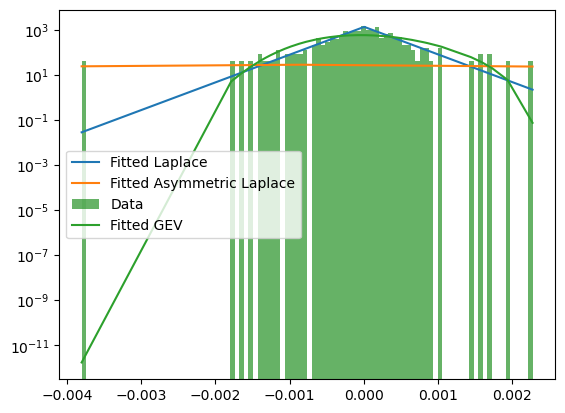

In [255]:
import numpy as np
from scipy.stats import genextreme
import matplotlib.pyplot as plt

# Example data (could be log-returns, etc.)
data = ticker_hist_date['logReturns']  # Replace with your actual data

# Fit GEV to the data
shape, loc, scale = genextreme.fit(data)

# Generate data from the fitted GEV distribution
gev_pdf = genextreme.pdf(np.sort(data), shape, loc=loc, scale=scale)

import numpy as np
from scipy.stats import laplace
import matplotlib.pyplot as plt

# Example data (replace with actual log-returns or other data)

# Fit Laplace distribution to the data
loc, scale = laplace.fit(data)  # loc is the mean, scale is the b parameter (scale parameter)
print(loc)
print(scale)
# Generate data from the fitted Laplace distribution
x = np.linspace(min(data), max(data), 1000)
laplace_pdf = laplace.pdf(x, loc, scale)

# Plot
plt.plot(x, laplace_pdf, label='Fitted Laplace')

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Asymmetric Laplace PDF
def asymmetric_laplace_pdf(x, mu, lambda_, kappa):
    coefficient = lambda_ / (kappa + 1/kappa)
    sign = np.sign(x - mu)
    abs_diff = np.abs(x - mu)
    return coefficient * np.exp(- lambda_ * abs_diff * kappa ** sign)

# Negative log-likelihood function
def negative_log_likelihood(params, data):
    mu, log_lambda, log_kappa = params
    lambda_ = np.exp(log_lambda)
    kappa = np.exp(log_kappa)
    pdf_values = asymmetric_laplace_pdf(data, mu, lambda_, kappa)
    return -np.sum(np.log(pdf_values))


# Initial parameter guesses (mu, log_lambda, log_kappa)
initial_params = [0, 0, 0]

# Minimize the negative log-likelihood to fit the parameters
result = minimize(negative_log_likelihood, initial_params, args=(data,), method='L-BFGS-B')
mu_hat, log_lambda_hat, log_kappa_hat = result.x
lambda_hat = np.exp(log_lambda_hat)
kappa_hat = np.exp(log_kappa_hat)

# Generate the fitted PDF
x = np.linspace(min(data), max(data), 1000)
fitted_pdf = asymmetric_laplace_pdf(x, mu_hat, lambda_hat, kappa_hat)

plt.plot(x, fitted_pdf, label='Fitted Asymmetric Laplace')




# Plot
plt.hist(data, bins=100, density=True, alpha=0.6, color='g', label='Data')
plt.plot(np.sort(data), gev_pdf, label='Fitted GEV')
plt.yscale('log')
#plt.ylim((10**1, 10**4))
plt.legend()
plt.show()

In [245]:
kappa_hat

np.float64(0.9999900590799505)

In [238]:
scale

np.float64(0.00025901184714129333)

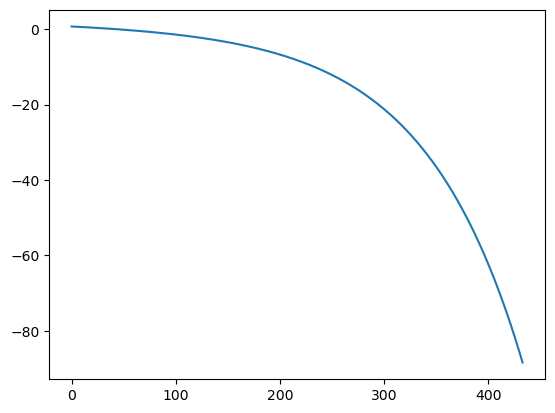

In [258]:
plt.plot(nlls)

(-0.001, 0.001)

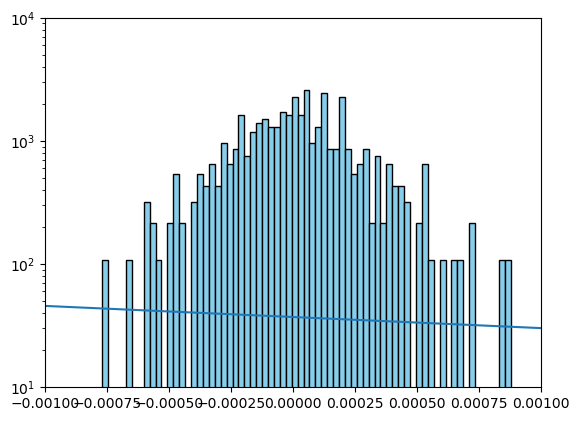

In [228]:
counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
plt.bar(
    x=bin_edges[:-1] + np.diff(bin_edges)[0]/2, 
    height=counts/(sum(counts)*np.diff(bin_edges)[0]),
    width=np.diff(bin_edges), 
    align='edge', 
    fc='skyblue', 
    ec='black'
)

plt.plot(torch.arange(-0.1, 0.1, 0.0001), torch.exp(ald(torch.arange(-0.1, 0.1, 0.0001))).detach().numpy())
plt.yscale('log')
plt.ylim((10**1, 10**4))
plt.xlim((-0.001, 0.001))

In [198]:
ald.log_kappa

Parameter containing:
tensor(-0.0116, requires_grad=True)

In [199]:
torch.arange(-1, 1, 0.001)

tensor([-1.0000, -0.9990, -0.9980,  ...,  0.9970,  0.9980,  0.9990])

In [192]:
ald.m

Parameter containing:
tensor(0.0049, requires_grad=True)

In [193]:
ald.log_kappa

Parameter containing:
tensor(-0.0116, requires_grad=True)

In [194]:
ald.log_lambda

Parameter containing:
tensor(4.8420, requires_grad=True)

In [ ]:
class TimeLaggedLoader(torch.utils.data.Dataset):
    """
    Dataset object for parameters of model. 
    Assumes parameters come in as a table, 
    """
    def __init__(
        self,
    )

In [2]:
a_params = {}
b_params = {}

price_performance = collections.defaultdict(list)
ticker = "VIXY"

# List Aggregates (Bars)
print('got here')

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)
    
print('finished pulling')

ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

a_params['VIXY'] = {}
b_params['VIXY'] = {}

print('analyzing')

for index, date in tqdm(enumerate(ticker_hist['Date'].unique())):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(ticker_hist_date['logReturns'])
    b = np.sum(
            np.abs(ticker_hist_date['logReturns'] - a)
    ) / len(ticker_hist_date)
    a_params[ticker][date] = a
    b_params[ticker][date] = b
print('finished analyzing')
tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

for ticker in tqdm(tickers['Symbol']):
    price_performance = collections.defaultdict(list)
    aggs = []
    for agg in client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)
    
    ticker_hist = pd.DataFrame(price_performance)
    
    ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
    ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)
    
    
    ticker_hist['logClose'] = np.log(ticker_hist['Close'])
    ticker_hist['logOpen'] = np.log(ticker_hist['Open'])
    
    ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']
    
    a_params[ticker] = {}
    b_params[ticker] = {}
    
    for index, date in enumerate(ticker_hist['Date'].unique()):
        ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
        #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
        a = np.median(ticker_hist_date['logReturns'])
        b = np.sum(
                np.abs(ticker_hist_date['logReturns'] - a)
        ) / len(ticker_hist_date)
        a_params[ticker][date] = a
        b_params[ticker][date] = b

got here


230513it [00:04, 55502.02it/s]


finished pulling
analyzing


503it [00:03, 146.51it/s]


finished analyzing
  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎ | 498/503 [1:46:12<01:03, 12.80s/it]


KeyboardInterrupt: 

In [4]:
tickers['Symbol'].iloc[-10:]

493      WY
494     WMB
495     WTW
496    WYNN
497     XEL
498     XYL
499     YUM
500    ZBRA
501     ZBH
502     ZTS
Name: Symbol, dtype: object

In [5]:
for ticker in tqdm(tickers['Symbol'][-10:]):
    price_performance = collections.defaultdict(list)
    aggs = []
    for agg in client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)
    
    ticker_hist = pd.DataFrame(price_performance)
    
    ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
    ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)
    
    
    ticker_hist['logClose'] = np.log(ticker_hist['Close'])
    ticker_hist['logOpen'] = np.log(ticker_hist['Open'])
    
    ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']
    
    a_params[ticker] = {}
    b_params[ticker] = {}
    
    for index, date in enumerate(ticker_hist['Date'].unique()):
        ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]
        #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
        a = np.median(ticker_hist_date['logReturns'])
        b = np.sum(
                np.abs(ticker_hist_date['logReturns'] - a)
        ) / len(ticker_hist_date)
        a_params[ticker][date] = a
        b_params[ticker][date] = b

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:16<00:00,  7.67s/it]


(array([8.00000e+00, 1.04000e+02, 1.92536e+05, 8.84000e+02, 1.20000e+01,
        2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-0.02256803, -0.01415571, -0.00574338,  0.00266894,  0.01108126,
         0.01949359,  0.02790591,  0.03631824,  0.04473056,  0.05314288,
         0.06155521]),
 <BarContainer object of 10 artists>)

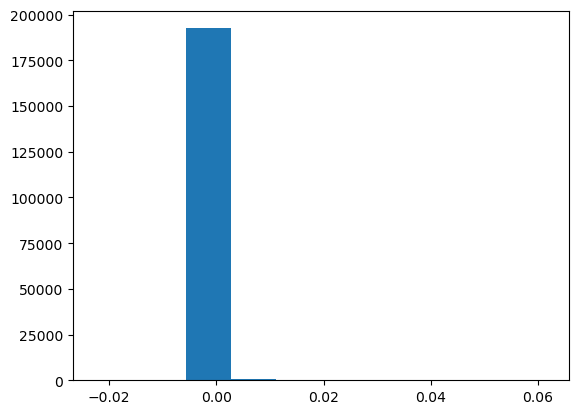

In [21]:
plt.hist(ticker_hist['logReturns'])

In [7]:
a_params_df = pd.DataFrame(a_params)
b_params_df = pd.DataFrame(b_params)

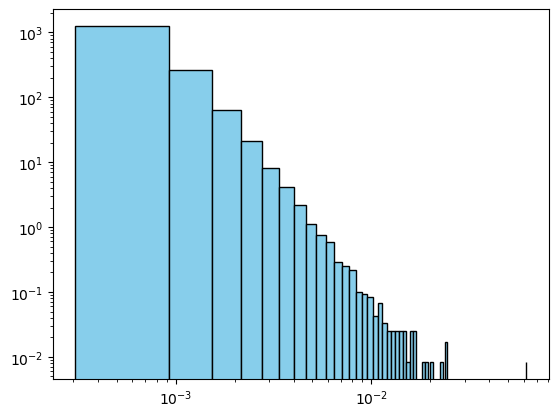

In [38]:
counts, bin_edges = np.histogram(np.abs(ticker_hist['logReturns']), bins=100)

plt.bar(
    x=bin_edges[:-1] + np.diff(bin_edges)[0]/2, 
    height=counts/(sum(counts)*np.diff(bin_edges)[0]),
    width=np.diff(bin_edges), 
    align='edge', 
    fc='skyblue', 
    ec='black'
)
plt.yscale('log')
plt.xscale('log')

In [39]:
pl

NameError: name 'x' is not defined

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:53<00:00,  5.36s/it]


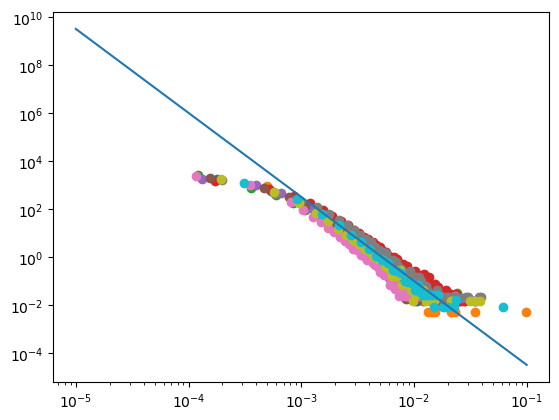

In [66]:
for ticker in tqdm(tickers['Symbol'][-10:]):
    price_performance = collections.defaultdict(list)
    aggs = []
    for agg in client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)
    
    ticker_hist = pd.DataFrame(price_performance)
    
    ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
    ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)
    
    
    ticker_hist['logClose'] = np.log(ticker_hist['Close'])
    ticker_hist['logOpen'] = np.log(ticker_hist['Open'])
    
    ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

    counts, bin_edges = np.histogram(np.abs(ticker_hist['logReturns']), bins=100)
    #plt.plot(np.arange(0.00001,0.1,0.0001), 0.00000001*np.arange(0.00001,0.1,0.0001) ** -3.5)
    plt.scatter(
        x=bin_edges[:-1] + np.diff(bin_edges)[0]/2, 
        y=counts/(sum(counts)*np.diff(bin_edges)[0]),
        #width=np.diff(bin_edges), 
        #align='edge', 
        #fc='skyblue', 
        #ec='black'
    )
    plt.yscale('log')
    plt.xscale('log')
plt.plot(np.arange(0.00001,0.1,0.0001), 0.00000001*np.arange(0.00001,0.1,0.0001) ** -3.5)


In [87]:
import statsmodels
import statsmodels.tsa.stattools


pacfs, confints = statsmodels.tsa.stattools.pacf(np.log(a_b_params_concat.iloc[:,504]), nlags = 40, alpha=0.05)

In [88]:
confints

array([[ 1.00000000e+00,  1.00000000e+00],
       [ 6.65077323e-01,  8.39858273e-01],
       [ 1.49489551e-02,  1.89729905e-01],
       [ 5.06717112e-02,  2.25452661e-01],
       [ 4.30711801e-03,  1.79088067e-01],
       [-7.08248427e-02,  1.03956107e-01],
       [-9.89312696e-02,  7.58496799e-02],
       [-9.35646248e-02,  8.12163246e-02],
       [-1.07558415e-01,  6.72225345e-02],
       [-4.60151846e-02,  1.28765765e-01],
       [-6.99177933e-02,  1.04863156e-01],
       [-1.62197950e-01,  1.25829999e-02],
       [-1.15987819e-01,  5.87931304e-02],
       [-6.05292589e-02,  1.14251691e-01],
       [-8.20348576e-02,  9.27460918e-02],
       [-2.02765234e-01, -2.79842850e-02],
       [-1.51891962e-01,  2.28889869e-02],
       [-3.72442862e-03,  1.71056521e-01],
       [-7.92331709e-02,  9.55477785e-02],
       [ 1.35329940e-02,  1.88313943e-01],
       [-4.12914431e-02,  1.33489506e-01],
       [-1.16736770e-01,  5.80441791e-02],
       [-1.03130636e-01,  7.16503135e-02],
       [-1.

In [89]:
confints[:,0]

array([ 1.        ,  0.66507732,  0.01494896,  0.05067171,  0.00430712,
       -0.07082484, -0.09893127, -0.09356462, -0.10755841, -0.04601518,
       -0.06991779, -0.16219795, -0.11598782, -0.06052926, -0.08203486,
       -0.20276523, -0.15189196, -0.00372443, -0.07923317,  0.01353299,
       -0.04129144, -0.11673677, -0.10313064, -0.17390179, -0.08991202,
       -0.12320769, -0.0753133 , -0.06620968,  0.00823069, -0.04887648,
       -0.09141502, -0.0731148 , -0.11938906, -0.12207393, -0.0906646 ,
       -0.04978859, -0.17938648, -0.12378978, -0.08545721, -0.08830681,
       -0.22958564])

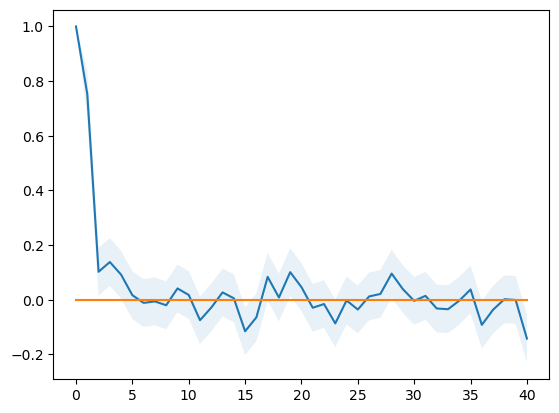

In [90]:
plt.plot(np.arange(41), pacfs)
plt.fill_between(np.arange(41), confints[:,0], confints[:,1], alpha=0.1)
plt.plot(np.arange(41), np.zeros(41))

In [96]:
import statsmodels.graphics.tsaplots

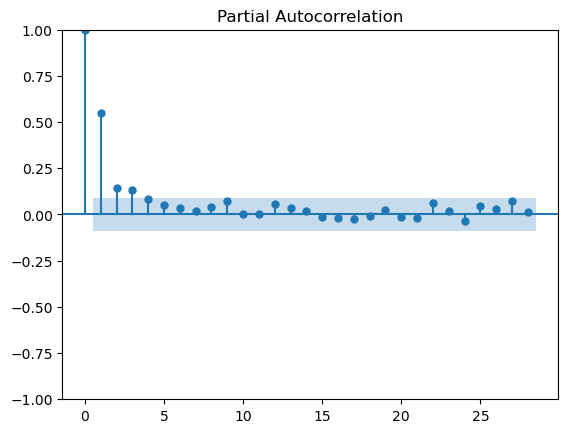

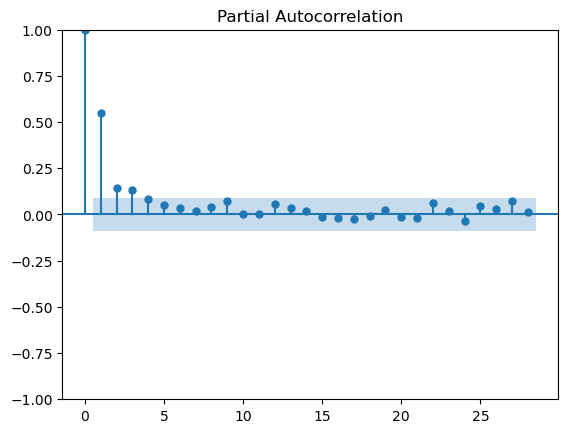

In [102]:
statsmodels.graphics.tsaplots.plot_pacf(a_b_params_concat.iloc[:,506])

In [120]:
np.corrcoef(np.log(a_b_params_concat.iloc[:-1,504]), np.log(a_b_params_concat.shift(-1).iloc[:-1,507]))

array([[1.        , 0.32331972],
       [0.32331972, 1.        ]])

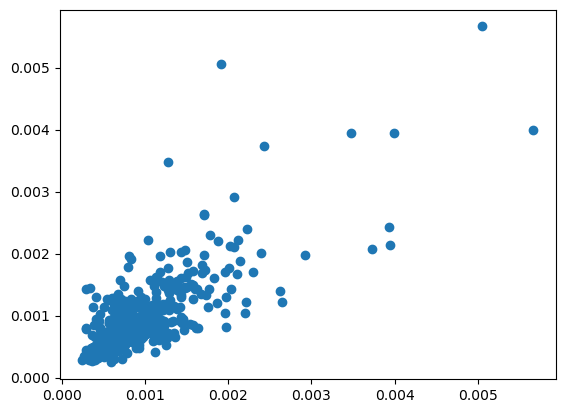

In [84]:
plt.scatter(a_b_params_concat.iloc[:, 504], a_b_params_concat.shift(-1).iloc[:,504])

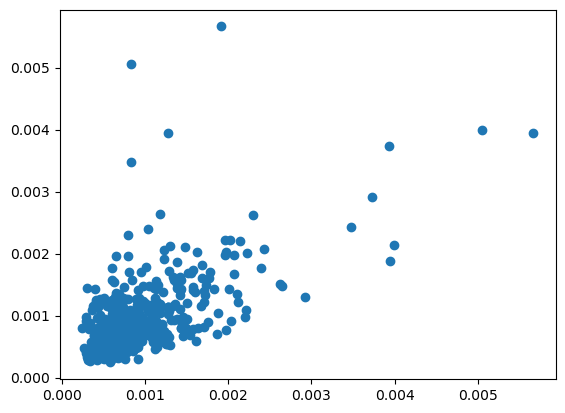

In [85]:
plt.scatter(a_b_params_concat.iloc[:, 504], a_b_params_concat.shift(-2).iloc[:,504])

In [103]:
import torch

In [9]:
a_b_params_concat = pd.concat([a_params_df.T, b_params_df.T]).T
targets = a_b_params_concat.shift(-1)

In [10]:
a_b_params_concat

,VIXY,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2022-09-21,0.000000,0.0,0.0,0.000000,0.000035,0.000000,0.000000,0.0,0.0,0.000000,...,0.000770,0.000658,0.000497,0.001153,0.000512,0.000627,0.000522,0.000697,0.000540,0.000625
2022-09-22,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000575,0.000535,0.000388,0.001070,0.000389,0.000422,0.000355,0.000581,0.000437,0.000534
2022-09-23,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000639,0.000729,0.000599,0.000961,0.000424,0.000444,0.000346,0.000452,0.000543,0.000584
2022-09-26,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000777,0.000799,0.000536,0.001276,0.000528,0.000579,0.000395,0.000541,0.000559,0.000531
2022-09-27,0.000291,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000735,0.000739,0.000459,0.001018,0.000543,0.000533,0.000428,0.000605,0.000569,0.000542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-16,0.000000,0.0,0.0,0.000013,0.000001,0.000000,0.000000,0.0,0.0,0.000000,...,0.000284,0.000319,0.000354,0.000398,0.000281,0.000279,0.000245,0.000235,0.000303,0.000240
2024-09-17,0.000000,0.0,0.0,0.000042,0.000000,-0.000048,0.000000,0.0,0.0,-0.000045,...,0.000441,0.000330,0.000162,0.000389,0.000231,0.000295,0.000317,0.000453,0.000439,0.000305
2024-09-18,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.000011,0.0,0.0,0.000000,...,0.000498,0.000399,0.000274,0.000571,0.000349,0.000530,0.000322,0.000657,0.000449,0.000459
2024-09-19,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000499,0.000316,0.000363,0.000458,0.000331,0.000366,0.000364,0.000448,0.000372,0.000584


In [11]:
targets

,VIXY,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2022-09-21,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000575,0.000535,0.000388,0.001070,0.000389,0.000422,0.000355,0.000581,0.000437,0.000534
2022-09-22,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000639,0.000729,0.000599,0.000961,0.000424,0.000444,0.000346,0.000452,0.000543,0.000584
2022-09-23,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000777,0.000799,0.000536,0.001276,0.000528,0.000579,0.000395,0.000541,0.000559,0.000531
2022-09-26,0.000291,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000735,0.000739,0.000459,0.001018,0.000543,0.000533,0.000428,0.000605,0.000569,0.000542
2022-09-27,0.000000,0.0,0.0,0.000000,0.000069,0.000025,0.000000,0.0,0.0,0.000000,...,0.000708,0.000520,0.000415,0.000923,0.000550,0.000491,0.000493,0.000421,0.000444,0.000493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-16,0.000000,0.0,0.0,0.000042,0.000000,-0.000048,0.000000,0.0,0.0,-0.000045,...,0.000441,0.000330,0.000162,0.000389,0.000231,0.000295,0.000317,0.000453,0.000439,0.000305
2024-09-17,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.000011,0.0,0.0,0.000000,...,0.000498,0.000399,0.000274,0.000571,0.000349,0.000530,0.000322,0.000657,0.000449,0.000459
2024-09-18,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000499,0.000316,0.000363,0.000458,0.000331,0.000366,0.000364,0.000448,0.000372,0.000584
2024-09-19,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000433,0.000313,0.000210,0.000420,0.000302,0.000356,0.000286,0.000329,0.000419,0.000404


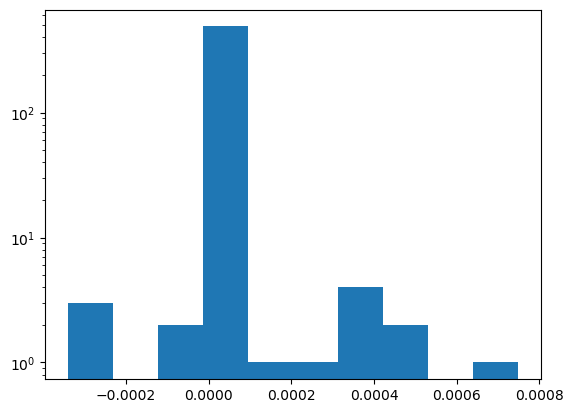

In [12]:
plt.hist(a_params_df.iloc[:,0])
plt.yscale('log')

In [13]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_a_b = scaler.fit_transform(a_b_params_concat)
scaled_targets = scaler.transform(targets)

In [14]:
a_b_params_concat.iloc[:-1, 505]

2022-09-21    0.000586
2022-09-22    0.000487
2022-09-23    0.000465
2022-09-26    0.000556
2022-09-27    0.000506
                ...   
2024-09-13    0.000352
2024-09-16    0.000380
2024-09-17    0.000394
2024-09-18    0.000549
2024-09-19    0.000424
Name: MMM, Length: 502, dtype: float64

In [15]:
print(np.corrcoef(a_b_params_concat.iloc[:-1,504], targets.iloc[:-1,504]))
print(np.corrcoef(a_b_params_concat.iloc[:-1,505], targets.iloc[:-1,505]))
print(np.corrcoef(a_b_params_concat.iloc[:-1,506], targets.iloc[:-1,506]))
print(np.corrcoef(np.log(a_b_params_concat.iloc[:-1,504]), np.log(targets.iloc[:-1,504])))
print(np.corrcoef(np.log(a_b_params_concat.iloc[:-1,505]), np.log(targets.iloc[:-1,505])))
print(np.corrcoef(np.log(a_b_params_concat.iloc[:-1,506]), np.log(targets.iloc[:-1,506])))
print(np.corrcoef(np.log(a_b_params_concat.iloc[:-1,507]), np.log(targets.iloc[:-1,507])))
print(np.corrcoef(np.log(a_b_params_concat.iloc[:-1,508]), np.log(targets.iloc[:-1,508])))
print(np.corrcoef(np.log(a_b_params_concat.iloc[:-1,509]), np.log(targets.iloc[:-1,509])))


[[1.         0.76533367]
 [0.76533367 1.        ]]
[[1.         0.39921734]
 [0.39921734 1.        ]]
[[1.         0.55365956]
 [0.55365956 1.        ]]
[[1.        0.7518431]
 [0.7518431 1.       ]]
[[1.         0.47174478]
 [0.47174478 1.        ]]
[[1.         0.65321941]
 [0.65321941 1.        ]]
[[1.         0.63662016]
 [0.63662016 1.        ]]
[[1.        0.5876038]
 [0.5876038 1.       ]]
[[1.         0.62785473]
 [0.62785473 1.        ]]


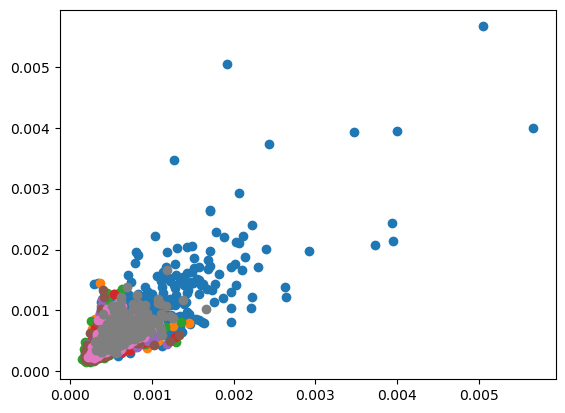

In [16]:
plt.scatter(a_b_params_concat.iloc[:-1,504], targets.iloc[:-1,504])
plt.scatter(a_b_params_concat.iloc[:-1,505], targets.iloc[:-1,505])
plt.scatter(a_b_params_concat.iloc[:-1,506], targets.iloc[:-1,506])
plt.scatter(a_b_params_concat.iloc[:-1,507], targets.iloc[:-1,507])
plt.scatter(a_b_params_concat.iloc[:-1,508], targets.iloc[:-1,508])
plt.scatter(a_b_params_concat.iloc[:-1,509], targets.iloc[:-1,509])
plt.scatter(a_b_params_concat.iloc[:-1,510], targets.iloc[:-1,510])
plt.scatter(a_b_params_concat.iloc[:-1,511], targets.iloc[:-1,511])
#plt.plot([-10,10],[-10,10],ls='--')
#plt.xlim([-10,-5])
#plt.ylim([-10,-5])


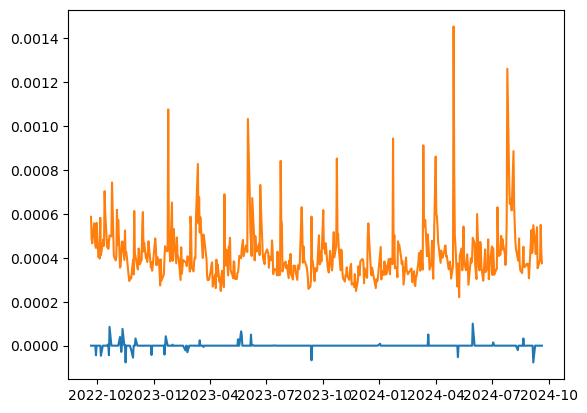

In [18]:
plt.plot(a_b_params_concat.iloc[:, 1])
plt.plot(a_b_params_concat.iloc[:, 505])


In [ ]:
plt.scatter(

In [146]:
a_b_params = a_b_params_concat.values
targets = targets.values

In [178]:
lasso.fit(scaled_a_b[:-1,[0,504]], scaled_targets[:-1,0])
lasso.score(scaled_a_b[:-1,[0,504]], scaled_targets[:-1,0])


0.015014882562493503

In [184]:
a_b_params_concat.corr()

,VIXY,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
VIXY,1.000000,-0.244256,-0.270675,-0.149030,-0.143667,-0.252483,-0.277087,-0.306249,-0.221398,-0.228163,...,0.070083,0.049163,0.075830,0.071581,0.129117,0.043238,0.059404,0.111734,0.113770,0.059590
MMM,-0.244256,1.000000,0.348572,0.191102,0.208100,0.307633,0.226278,0.229662,0.324411,0.229378,...,0.059447,-0.057512,0.037045,0.005621,0.039581,-0.048912,0.030313,0.010169,-0.060970,0.007866
AOS,-0.270675,0.348572,1.000000,0.173711,0.118447,0.287129,0.205398,0.300940,0.270296,0.240618,...,-0.016825,-0.024178,-0.096074,-0.063345,-0.022876,-0.054077,-0.011262,-0.081304,-0.113501,-0.001939
ABT,-0.149030,0.191102,0.173711,1.000000,0.269672,0.275720,0.225897,0.169992,0.197750,0.158314,...,-0.034733,-0.007111,-0.065779,-0.040087,-0.006993,0.022241,-0.057069,0.005165,-0.086644,-0.069589
ABBV,-0.143667,0.208100,0.118447,0.269672,1.000000,0.149020,0.045105,-0.002755,0.084466,0.169631,...,-0.052166,0.018631,0.055663,0.030743,-0.000265,0.025883,0.058147,0.008244,-0.061323,0.029698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.043238,-0.048912,-0.054077,0.022241,0.025883,-0.036545,-0.013721,0.028767,-0.096445,-0.026678,...,0.576567,0.575229,0.435340,0.476118,0.358828,1.000000,0.552221,0.535477,0.461297,0.419508
YUM,0.059404,0.030313,-0.011262,-0.057069,0.058147,-0.072468,-0.087749,-0.056876,-0.043068,0.039175,...,0.566813,0.559652,0.422954,0.548517,0.468220,0.552221,1.000000,0.486694,0.518464,0.490114
ZBRA,0.111734,0.010169,-0.081304,0.005165,0.008244,-0.086322,-0.123292,0.007742,-0.052360,-0.034583,...,0.459284,0.442016,0.349566,0.402673,0.327757,0.535477,0.486694,1.000000,0.477098,0.429984
ZBH,0.113770,-0.060970,-0.113501,-0.086644,-0.061323,-0.056025,-0.044043,-0.050003,-0.080098,-0.090470,...,0.419989,0.421558,0.315045,0.430787,0.316070,0.461297,0.518464,0.477098,1.000000,0.408501


In [172]:
lasso.fit(scaled_a_b[:-1,[1,505]], scaled_targets[:-1,505])

lasso.score(scaled_a_b[:-1,[1,505]], scaled_targets[:-1,505])


0.1659194851395629

In [157]:
lasso.coef_

array([0.06347402, 0.7524393 ])

In [153]:
np.corrcoef(a_b_params[:-1,504], targets[:-1,504])

array([[1.        , 0.76640648],
       [0.76640648, 1.        ]])

In [145]:
lasso = Ridge()
lasso.fit(a_b_params_concat.iloc[:-1,504].values.reshape(1,-1), targets.iloc[:-1,504])
lasso.score(a_b_params_concat.iloc[:-1,504].values.reshape(1,-1), targets.iloc[:-1,504])


ValueError: Found input variables with inconsistent numbers of samples: [1, 502]

In [127]:
np.corrcoef(np.log(a_b_params_concat.iloc[:-1,506]), np.log(targets.iloc[:-1,506]))


array([[1.        , 0.65946073],
       [0.65946073, 1.        ]])

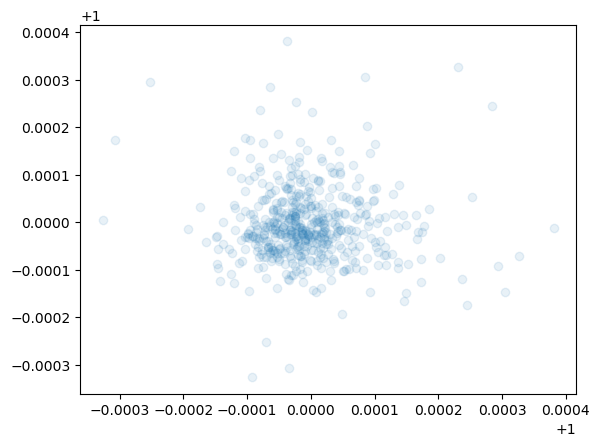

In [135]:
plt.scatter(np.exp(a_b_params_concat.iloc[:,0]), np.exp(targets.iloc[:,0]), alpha=0.1)



In [106]:
scaled_a_b[:-1,505]

array([ 1.10694318e+00,  2.15259252e+00,  1.21784606e+00,  9.10628733e-01,
        1.33029432e+00,  5.23526481e-01,  1.03999537e+00,  1.64450382e+00,
        7.99880266e-01,  6.07291766e-01,  1.39149120e+00,  9.49475397e-01,
        5.58930195e-01,  4.31920571e-01,  1.39184532e+00,  1.18030306e-01,
        1.67523357e-01,  3.23731095e-02,  1.62186569e+00,  1.58981607e-01,
        6.17057150e-01,  7.57733103e-01,  5.22768723e-01,  2.61176936e+00,
        1.81102447e+00,  4.74660775e-01,  7.30216002e-01,  4.15179272e-01,
        6.77477329e-01,  9.16341468e-01,  8.81816432e-01,  2.94553465e+00,
        1.90179995e+00,  9.98125233e-01,  1.55919954e-01, -4.06094782e-02,
        1.17508340e-01,  1.91943369e+00,  5.45474595e-01,  1.50825954e+00,
       -3.06929503e-01, -2.11349231e-01,  2.62828326e-01,  7.15946898e-01,
        6.86942282e-01, -1.28220021e-02,  1.10938795e+00,  1.71119632e-01,
        2.80693751e-01,  1.09175006e-01, -6.34188436e-01, -8.10922312e-01,
       -6.70604245e-01, -

In [103]:
np.corrcoef(scaled_a_b[:-1,504], scaled_targets[:-1,504])
np.corrcoef(np.log(scaled_a_b[:-1,504]), np.log(scaled_targets[:-1,504]))


/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_75532/1939824799.py:2: RuntimeWarning: divide by zero encountered in log
  np.corrcoef(np.log(scaled_a_b[:-1,504]), np.log(scaled_targets[:-1,504]))
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_75532/1939824799.py:2: RuntimeWarning: invalid value encountered in log
  np.corrcoef(np.log(scaled_a_b[:-1,504]), np.log(scaled_targets[:-1,504]))


array([[nan, nan],
       [nan, nan]])

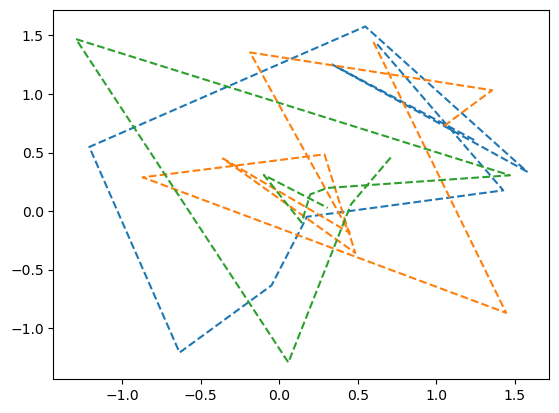

In [91]:
plt.plot(scaled_a_b[:10,0], scaled_targets[:10,0], ls='--')
plt.plot(scaled_a_b[10:20,0], scaled_targets[10:20,0], ls='--')
plt.plot(scaled_a_b[20:30,0], scaled_targets[20:30,0], ls='--')


array([-0.14018201,  0.79522755,  0.71525772,  0.60101899,  0.66160958,
        0.25523339,  0.27107184,  1.13726515,  0.86934521,  1.37918207])

In [95]:
scaled_targets[:10, 504]

array([0.79522755, 0.71525772, 0.60101899, 0.66160958, 0.25523339,
       0.27107184, 1.13726515, 0.86934521, 1.37918207, 1.63561258])

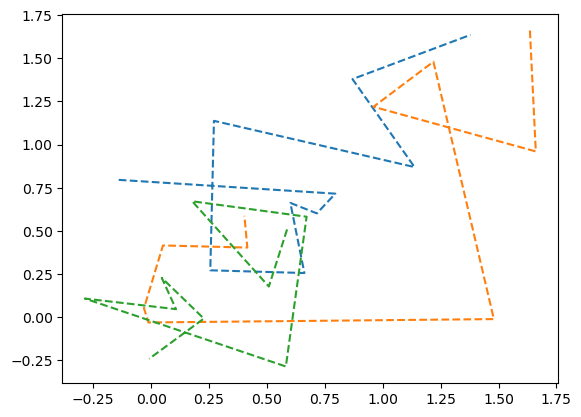

In [92]:
plt.plot(scaled_a_b[:10,504], scaled_targets[:10,504], ls='--')
plt.plot(scaled_a_b[10:20,504], scaled_targets[10:20,504], ls='--')
plt.plot(scaled_a_b[20:30,504], scaled_targets[20:30,504], ls='--')

,VIXY,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2022-09-12,0.000036,0.000011,-2.445678e-05,7.908219e-06,0.000014,0.000011,2.268870e-05,-0.000016,-0.000027,0.000020,...,0.000396,0.000460,0.000279,0.000570,0.000315,0.000356,0.000327,0.000403,0.000607,0.000401
2022-09-13,0.000103,-0.000072,-6.960872e-05,-8.316292e-05,-0.000053,-0.000121,-1.540321e-04,-0.000138,-0.000096,-0.000079,...,0.000537,0.000557,0.000347,0.000709,0.000411,0.000394,0.000344,0.000551,0.000476,0.000442
2022-09-14,-0.000002,-0.000069,-8.984750e-05,-5.155406e-06,0.000010,-0.000018,1.924912e-06,0.000011,0.000019,-0.000029,...,0.000687,0.000523,0.000271,0.000934,0.000370,0.000406,0.000389,0.000443,0.000505,0.000492
2022-09-15,-0.000021,-0.000034,1.111538e-05,-2.066888e-05,0.000034,-0.000031,-3.234598e-04,-0.000036,0.000002,-0.000028,...,0.000546,0.000511,0.000320,0.001172,0.000421,0.000419,0.000348,0.000472,0.000366,0.000431
2022-09-16,-0.000070,0.000030,1.486530e-05,4.818878e-07,0.000052,0.000016,-2.102514e-05,0.000027,-0.000117,0.000013,...,0.000588,0.000598,0.000482,0.000855,0.000412,0.000513,0.000340,0.000527,0.000467,0.000528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-05,-0.000080,-0.000013,-6.766094e-05,-2.023682e-05,-0.000054,-0.000023,-4.206595e-05,-0.000027,0.000016,-0.000019,...,0.000341,0.000341,0.000197,0.000378,0.000295,0.000332,0.000183,0.000347,0.000988,0.000318
2024-09-06,0.000237,-0.000045,-3.973349e-05,1.577206e-05,0.000004,-0.000011,-1.369593e-05,-0.000047,-0.000083,-0.000020,...,0.000433,0.000442,0.000249,0.000469,0.000327,0.000406,0.000283,0.000477,0.000427,0.000440
2024-09-09,-0.000120,-0.000003,1.438416e-05,5.333963e-05,0.000027,0.000009,1.295035e-07,0.000038,0.000017,0.000012,...,0.000317,0.000309,0.000237,0.000329,0.000288,0.000352,0.000285,0.000342,0.000404,0.000318
2024-09-10,-0.000016,0.000032,2.055792e-05,2.994241e-05,0.000023,0.000046,6.619614e-06,0.000044,0.000029,-0.000023,...,0.000375,0.000348,0.000271,0.000414,0.000300,0.000274,0.000287,0.000316,0.000333,0.000464


In [71]:
from sklearn.linear_model import Lasso, Ridge
train_rsquareds = []

for i in range(scaled_targets.shape[1]):
    
    ridge_regressor = Lasso()
    ridge_regressor.fit(scaled_a_b[:-1, 0], scaled_targets[:-1, 0])
    train_rsquareds.append(ridge_regressor.score(scaled_a_b[:-1, :], scaled_targets[:-1, i]))

ValueError: Input X contains NaN.
Lasso does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [84]:
ridge_regressor = Ridge()

ridge_regressor.fit(scaled_a_b[:-1, [0,504]], scaled_targets[:-1, 504])
ridge_regressor.score(scaled_a_b[:-1, [0,504]], scaled_targets[:-1, 504])

0.5902456926213115

In [81]:
ridge_regressor.coef_

array([0.08823692, 0.38758389])

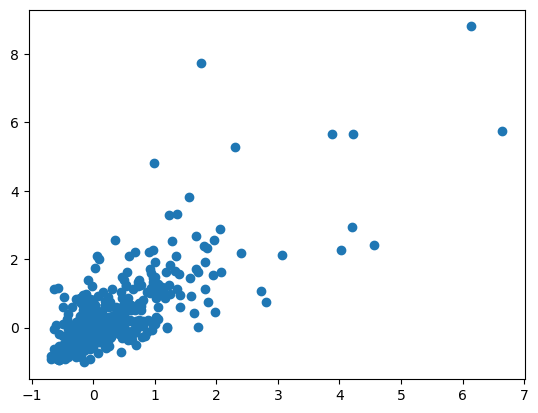

In [78]:
plt.scatter(ridge_regressor.predict(scaled_a_b[:-1, [0,504]]), scaled_targets[:-1, 504])

(array([969.,   1.,   2.,   1.,   0.,   1.,   1.,   3.,   0.,   2.]),
 array([0.        , 0.03108303, 0.06216606, 0.09324909, 0.12433212,
        0.15541516, 0.18649819, 0.21758122, 0.24866425, 0.27974728,
        0.31083031]),
 <BarContainer object of 10 artists>)

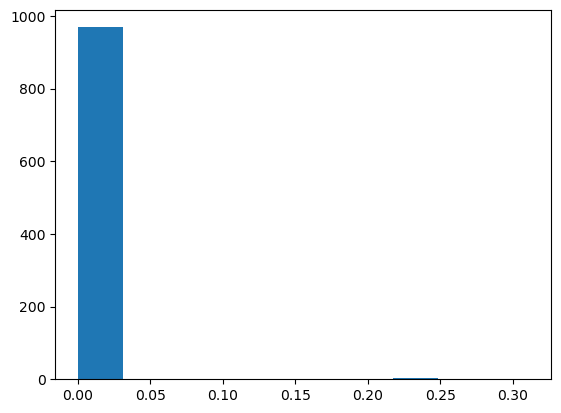

In [57]:
plt.hist(train_rsquareds)

In [39]:
ridge_regressor = Ridge()
ridge_regressor.fit(scaled_a_b[:-1, :10], scaled_targets[:-1, 0])
ridge_regressor.score(scaled_a_b[:-1, :10], scaled_targets[:-1, 0])

0.02067810678420723

In [41]:
a_params_df

,VIXY,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,...,WY,WMB,WTW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2022-09-12,0.000036,0.000011,-2.445678e-05,7.908219e-06,0.000014,0.000011,2.268870e-05,-0.000016,-0.000027,0.000020,...,-2.131682e-05,0.000060,1.754246e-05,0.000054,0.000016,0.000035,0.000002,0.000014,0.000084,0.000031
2022-09-13,0.000103,-0.000072,-6.960872e-05,-8.316292e-05,-0.000053,-0.000121,-1.540321e-04,-0.000138,-0.000096,-0.000079,...,-1.595176e-04,-0.000084,-8.190394e-05,-0.000086,-0.000073,-0.000041,-0.000022,-0.000139,-0.000013,-0.000019
2022-09-14,-0.000002,-0.000069,-8.984750e-05,-5.155406e-06,0.000010,-0.000018,1.924912e-06,0.000011,0.000019,-0.000029,...,-4.882031e-05,0.000047,4.365604e-07,-0.000066,0.000010,0.000021,0.000023,0.000032,0.000012,-0.000016
2022-09-15,-0.000021,-0.000034,1.111538e-05,-2.066888e-05,0.000034,-0.000031,-3.234598e-04,-0.000036,0.000002,-0.000028,...,-3.888350e-05,-0.000069,-3.394549e-06,0.000102,-0.000057,-0.000002,0.000011,0.000024,-0.000017,-0.000021
2022-09-16,-0.000070,0.000030,1.486530e-05,4.818878e-07,0.000052,0.000016,-2.102514e-05,0.000027,-0.000117,0.000013,...,-4.705976e-05,-0.000078,-6.338964e-06,0.000016,0.000023,0.000015,0.000028,-0.000103,-0.000057,-0.000023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-05,-0.000080,-0.000013,-6.766094e-05,-2.023682e-05,-0.000054,-0.000023,-4.206595e-05,-0.000027,0.000016,-0.000019,...,-8.411172e-07,0.000019,-6.040395e-06,-0.000017,-0.000002,-0.000036,-0.000006,0.000041,-0.000200,-0.000015
2024-09-06,0.000237,-0.000045,-3.973349e-05,1.577206e-05,0.000004,-0.000011,-1.369593e-05,-0.000047,-0.000083,-0.000020,...,2.346461e-05,-0.000047,-3.494148e-05,-0.000018,-0.000033,-0.000031,-0.000012,-0.000093,-0.000005,0.000022
2024-09-09,-0.000120,-0.000003,1.438416e-05,5.333963e-05,0.000027,0.000009,1.295035e-07,0.000038,0.000017,0.000012,...,-1.176469e-05,0.000002,3.852010e-05,0.000008,0.000020,0.000044,-0.000012,0.000093,-0.000009,0.000016
2024-09-10,-0.000016,0.000032,2.055792e-05,2.994241e-05,0.000023,0.000046,6.619614e-06,0.000044,0.000029,-0.000023,...,6.281911e-05,-0.000006,-3.290983e-05,-0.000069,0.000006,0.000007,-0.000004,0.000091,0.000012,-0.000008


array([[1.        , 0.26680668],
       [0.26680668, 1.        ]])

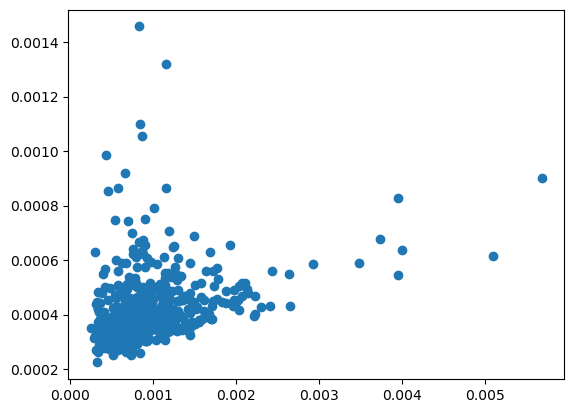

In [55]:
plt.scatter(b_params_df.iloc[:,0], b_params_df.iloc[:,1])
np.corrcoef(b_params_df.iloc[:,0], b_params_df.iloc[:,4])

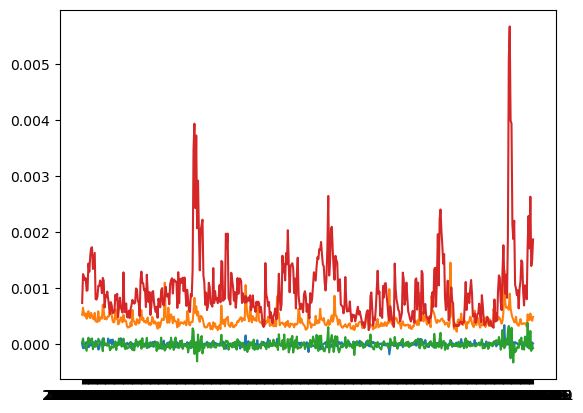

In [49]:
plt.plot(a_params_df.iloc[:,1])
plt.plot(b_params_df.iloc[:,1])

plt.plot(a_params_df.iloc[:,0])
plt.plot(b_params_df.iloc[:,0])


In [27]:
a_b_params_concat.iloc[:,725]

2022-09-12    0.000566
2022-09-13    0.000644
2022-09-14    0.000680
2022-09-15    0.000676
2022-09-16    0.000800
                ...   
2024-09-05    0.000488
2024-09-06    0.000569
2024-09-09    0.000615
2024-09-10    0.000614
2024-09-11    0.000586
Name: HBAN, Length: 503, dtype: float64

In [21]:
np.where(np.asarray(train_rsquareds)>0.2)

(array([592, 683, 704, 725, 755, 932]),)

In [80]:
aggs[1]

Agg(open=13.08, high=13.08, low=13.08, close=13.08, volume=523, vwap=13.08, timestamp=1725956880000, transactions=3, otc=None)

In [81]:
price_performance = collections.defaultdict(list)
for agg in aggs:
    price_performance['open'].append(agg.open)
    price_performance['close'].append(agg.close)
    price_performance['high'].append(agg.high)
    price_performance['low'].append(agg.low)
    price_performance['volume'].append(agg.volume)
    price_performance['timestamp'].append(agg.timestamp)
    price_performance['transactions'].append(agg.transactions)
    
    

In [82]:
price_performance_pd = pd.DataFrame(price_performance)

In [83]:
price_performance_pd['logOpen'] = np.log(price_performance_pd['open'])
price_performance_pd['logClose'] = np.log(price_performance_pd['close'])


price_performance_pd['logReturns'] = price_performance_pd['logClose'] - price_performance_pd['logOpen']

In [84]:
a = (price_performance_pd['logClose'].iloc[-1]- price_performance_pd['logOpen'].iloc[0])/len(price_performance_pd)
a = np.median(price_performance_pd['logReturns'])
b = np.mean(np.absolute(price_performance_pd['logReturns'] - a))

In [85]:
def laplace_fit(x, b, a):
    return 1/(2*b) * np.exp(-np.abs(x - a) / b)

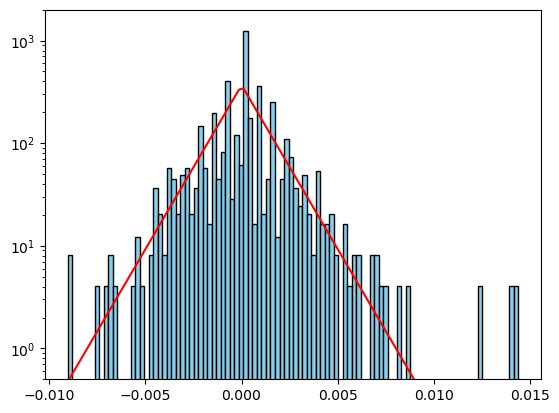

In [86]:
counts, bin_edges = np.histogram(price_performance_pd['logReturns'], bins=100)
plt.bar(
    x=bin_edges[:-1] + np.diff(bin_edges)[0]/2, 
    height=counts/(sum(counts)*np.diff(bin_edges)[0]),
    width=np.diff(bin_edges), 
    align='edge', 
    fc='skyblue', 
    ec='black'
)

plt.plot(bin_edges[:-1] + np.diff(bin_edges)[0]/2, laplace_fit(bin_edges[:-1] + np.diff(bin_edges)[0]/2 , b, a), color='red')

plt.ylim(0.5, 2000)
plt.yscale('log')

In [13]:
tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

NameError: name 'pd' is not defined